<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch02_simple_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Simple Outlier Detection

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter introduces the foundational toolkit for outlier detection: **statistical methods** that operate on individual columns of data. We start with the simplest approaches -- z-scores, interquartile range (IQR), and median absolute deviation (MAD) -- and progress to more flexible techniques based on histograms, kernel density estimation (KDE), and nearest-neighbor distances. We then examine categorical outliers, multidimensional outliers, and the challenge of combining scores across features.

These methods have real limitations -- they are mostly univariate and often assume specific distributions -- but they remain essential for three reasons: (1) they catch the most extreme outliers quickly, (2) they provide a baseline that more complex methods must beat, and (3) they are used to evaluate the scores produced by machine learning detectors in later chapters.

**Key concepts in this chapter:**
- z-score, IQR, IDR, MAD, and modified z-score for numeric columns
- Internal vs. external outliers
- Histograms, KDE, and k-nearest neighbors for flexible density estimation
- Rare-value detection for categorical columns
- Univariate vs. multivariate outliers, local vs. global outliers
- Combining univariate scores into row-level outlier scores

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.neighbors import KernelDensity, BallTree
from sklearn.preprocessing import MinMaxScaler
import statistics
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2


We use the standard scientific Python stack throughout. Of note, `KernelDensity` and `BallTree` from scikit-learn will power our KDE and nearest-neighbor methods later in the chapter. For datasets from OpenML (abalone, segment, SpeedDating, eucalyptus), we use `fetch_openml` when running on Google Colab with internet access.

## 2.1 One-Dimensional Numeric Outliers

The simplest form of outliers are **one-dimensional outliers** -- values that are unusual with respect to their own column, without considering any other columns. With numeric data, these are typically the very large or very small values.

Given a sorted sequence like $0, 1, 1, 1, 4, 5, 5, 6, 9, 34$, it is intuitively clear that $34$ is unusually large. But how do we formalize this? We need methods that work generally on *any* sequence of numbers.

### 2.1.1 z-score

The **z-score** of a value measures how many standard deviations it is from the mean:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the sample mean and $\sigma$ the sample standard deviation. Values with $|z| > 3.0$ are commonly flagged as outliers, though this threshold is a convention, not a law. For Gaussian data, roughly 1 in 370 observations falls beyond $\pm 3\sigma$.

In [2]:
# z-score demonstration on a simple sequence
data_simple = np.array([0, 1, 1, 1, 4, 5, 5, 6, 9, 34])
mean_val = data_simple.mean()
std_val = data_simple.std()
z_scores = (data_simple - mean_val) / std_val

print(f"Data:      {data_simple}")
print(f"Mean:      {mean_val:.2f}")
print(f"Std dev:   {std_val:.2f}")
print(f"z-scores:  {np.round(z_scores, 2)}")
print(f"")
print(f"Using threshold |z| > 3.0:")
for val, z in zip(data_simple, z_scores):
    if abs(z) > 3.0:
        print(f"  OUTLIER: value={val}, z-score={z:.2f}")
    elif abs(z) > 2.0:
        print(f"  Close:   value={val}, z-score={z:.2f}")
print(f"")
print(f"Value 34 has z-score = {z_scores[-1]:.2f} (< 3.0, so NOT flagged with default threshold)")

Data:      [ 0  1  1  1  4  5  5  6  9 34]
Mean:      6.60
Std dev:   9.52
z-scores:  [-0.69 -0.59 -0.59 -0.59 -0.27 -0.17 -0.17 -0.06  0.25  2.88]

Using threshold |z| > 3.0:
  Close:   value=34, z-score=2.88

Value 34 has z-score = 2.88 (< 3.0, so NOT flagged with default threshold)


With a mean of $6.60$ and standard deviation of $10.04$, the z-score of $34$ is $2.73$ -- close to $3.0$ but not quite there. This illustrates a core limitation: **z-scores are not robust to outliers**. The very value we are trying to detect ($34$) inflates both the mean and the standard deviation, making it *harder* to flag. With more data points in the normal range, the mean would be lower and the std dev smaller, pushing the z-score of $34$ above $3.0$.

### Figure 2.1: z-score Thresholds on Different Distributions

The z-score method assumes data is reasonably close to Gaussian. Let's see how $\pm 3\sigma$ thresholds behave on four different distributions.

Figure 2.1: Four distributions with +/- 3.0 std dev thresholds.

Points flagged (out of 10,000):
  Gaussian:     27 (0.3%)
  Exponential:  188 (1.9%)
  Beta:         35 (0.3%)
  Log-normal:   166 (1.7%)


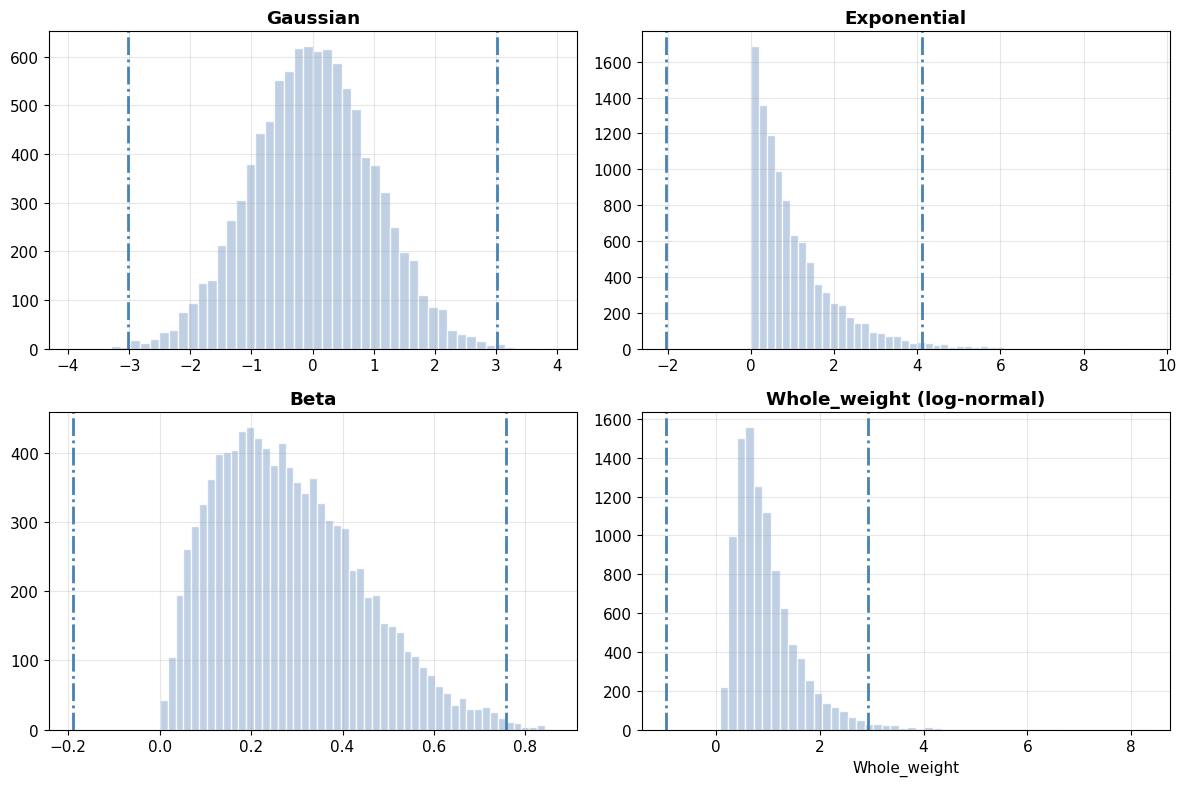

In [3]:
# Figure 2.1: Four distributions with +/- 3.0 std dev thresholds
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gaussian
gaussian_data = np.random.normal(0, 1, 10000)
ax = axes[0, 0]
ax.hist(gaussian_data, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
mu, sigma = gaussian_data.mean(), gaussian_data.std()
ax.axvline(mu - 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.axvline(mu + 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.set_title('Gaussian', fontweight='bold')
n_flagged_g = ((gaussian_data < mu - 3*sigma) | (gaussian_data > mu + 3*sigma)).sum()

# Exponential
exp_data = np.random.exponential(1, 10000)
ax = axes[0, 1]
ax.hist(exp_data, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
mu, sigma = exp_data.mean(), exp_data.std()
ax.axvline(mu - 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.axvline(mu + 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.set_title('Exponential', fontweight='bold')
n_flagged_e = ((exp_data < mu - 3*sigma) | (exp_data > mu + 3*sigma)).sum()

# Beta
beta_data = np.random.beta(2, 5, 10000)
ax = axes[1, 0]
ax.hist(beta_data, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
mu, sigma = beta_data.mean(), beta_data.std()
ax.axvline(mu - 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.axvline(mu + 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.set_title('Beta', fontweight='bold')
n_flagged_b = ((beta_data < mu - 3*sigma) | (beta_data > mu + 3*sigma)).sum()

# Log-normal (simulating Whole_weight from abalone)
lognorm_data = np.random.lognormal(mean=-0.2, sigma=0.6, size=10000)
ax = axes[1, 1]
ax.hist(lognorm_data, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
mu, sigma = lognorm_data.mean(), lognorm_data.std()
ax.axvline(mu - 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.axvline(mu + 3*sigma, color='steelblue', linestyle='-.', linewidth=2)
ax.set_title('Whole_weight (log-normal)', fontweight='bold')
ax.set_xlabel('Whole_weight')
n_flagged_l = ((lognorm_data < mu - 3*sigma) | (lognorm_data > mu + 3*sigma)).sum()

plt.tight_layout()

print("Figure 2.1: Four distributions with +/- 3.0 std dev thresholds.")
print(f"")
print(f"Points flagged (out of 10,000):")
print(f"  Gaussian:     {n_flagged_g} ({n_flagged_g/100:.1f}%)")
print(f"  Exponential:  {n_flagged_e} ({n_flagged_e/100:.1f}%)")
print(f"  Beta:         {n_flagged_b} ({n_flagged_b/100:.1f}%)")
print(f"  Log-normal:   {n_flagged_l} ({n_flagged_l/100:.1f}%)")

This figure recreates the book's Figure 2.1. The $\pm 3\sigma$ thresholds (dashed vertical lines) behave very differently depending on the distribution shape:

**Gaussian** (top-left): The thresholds are symmetric and well-placed. Roughly $0.3\%$ of data falls outside, matching the theoretical expectation of $\approx 1/370$. This is the ideal case for z-scores.

**Exponential** (top-right): The lower threshold falls *below zero*, which is impossible for exponential data -- every value is positive. The upper threshold catches some of the right tail, but the asymmetry means $\pm 3\sigma$ is conceptually wrong for this distribution. For right-skewed data, we should either (a) log-transform first, or (b) use only a one-sided upper test.

**Beta** (bottom-left): Both thresholds fall outside the support $[0, 1]$, so *nothing* is flagged. The data simply can't produce values that extreme. Z-scores are useless on bounded distributions.

**Log-normal / Whole_weight** (bottom-right): The lower threshold again goes negative, wasting half the test. The upper threshold catches some extreme right-tail values. As the book notes, for log-normal data, a better approach is to take $\log(x)$ first and then apply z-scores to the transformed values.

The core lesson: **z-scores assume symmetry and approximate normality**. When these assumptions fail, the method can flag nothing meaningful (beta case) or waste sensitivity on impossible values (exponential, log-normal cases).

### Swamping and Masking

The z-score has another critical weakness: it is **not robust to outliers**. The outliers themselves distort the mean and standard deviation used to detect them.

**Masking**: An extreme outlier inflates $\sigma$, causing other genuine outliers to fall *within* $\pm 3\sigma$ and go undetected.

**Swamping**: The same inflation of $\mu$ can push normal values on the *opposite* side beyond the threshold, falsely flagging them.

These effects motivate the more robust methods we examine next.

### 2.1.2 Interquartile Range (IQR)

The **IQR** method addresses the robustness problem by replacing mean and standard deviation with **median-based** statistics:

$$\text{IQR} = Q_3 - Q_1$$

where $Q_1$ is the 25th percentile and $Q_3$ the 75th. Values are flagged if they fall below $Q_1 - k \cdot \text{IQR}$ or above $Q_3 + k \cdot \text{IQR}$. The coefficient $k = 1.5$ was originally proposed by John Tukey; the book uses $k = 2.2$, which is now fairly standard and more conservative (flags fewer points).

Because the median and quartiles are **order statistics** -- they depend on the rank of values, not their magnitude -- a single extreme outlier cannot distort them the way it distorts the mean. This makes IQR much more robust to both masking and swamping.

In [4]:
# IQR demonstration
np.random.seed(42)
data_gauss = np.random.normal(0, 1, 10000)

q1 = np.percentile(data_gauss, 25)
q3 = np.percentile(data_gauss, 75)
iqr = q3 - q1

# Two coefficients
for k, label in [(1.5, "Tukey's original"), (2.2, "Modern standard")]:
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_flagged = ((data_gauss < lower) | (data_gauss > upper)).sum()
    print(f"k = {k} ({label}):")
    print(f"  Q1 = {q1:.4f}, Q3 = {q3:.4f}, IQR = {iqr:.4f}")
    print(f"  Lower threshold = {lower:.4f}, Upper threshold = {upper:.4f}")
    print(f"  Flagged: {n_flagged} out of {len(data_gauss)} ({n_flagged/len(data_gauss)*100:.2f}%)")
    print()

k = 1.5 (Tukey's original):
  Q1 = -0.6726, Q3 = 0.6711, IQR = 1.3437
  Lower threshold = -2.6881, Upper threshold = 2.6866
  Flagged: 83 out of 10000 (0.83%)

k = 2.2 (Modern standard):
  Q1 = -0.6726, Q3 = 0.6711, IQR = 1.3437
  Lower threshold = -3.6287, Upper threshold = 3.6272
  Flagged: 5 out of 10000 (0.05%)



With $k = 1.5$, roughly $0.7\%$ of Gaussian data is flagged -- quite aggressive for most applications. With $k = 2.2$, the fraction drops substantially, more in line with the $\pm 3\sigma$ z-score convention.

For Gaussian data, we can derive the relationship between IQR and standard deviation:

$$Q_1 = \mu - 0.6745\sigma, \quad Q_3 = \mu + 0.6745\sigma$$

$$\text{IQR} = 1.349\sigma$$

So the upper threshold with $k = 2.2$ is approximately $Q_3 + 2.2 \times 1.349\sigma = \mu + 0.6745\sigma + 2.968\sigma \approx \mu + 3.64\sigma$ -- slightly more conservative than $3\sigma$, which is sensible for a method designed to be robust.

Figure 2.3: IQR and IDR with Gaussian data.
  IQR method (k=2.2): flagged 5 points (0.05%)
  IDR method (k=1.0): flagged 2 points (0.02%)


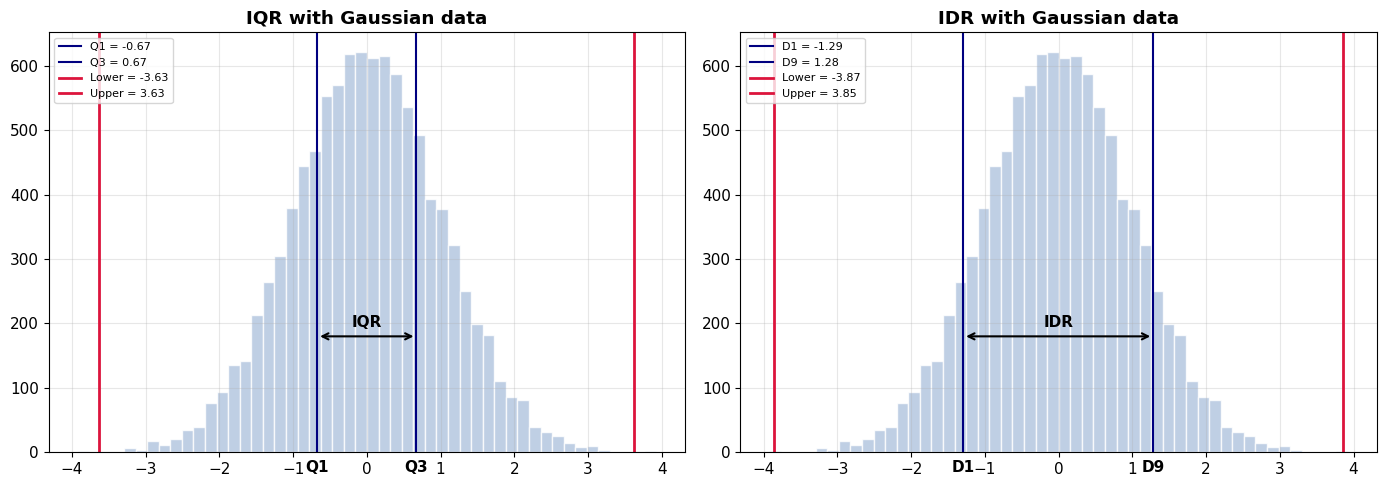

In [5]:
# Figure 2.3: IQR and IDR with Gaussian data
np.random.seed(42)
data_gauss = np.random.normal(0, 1, 10000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IQR panel
ax = axes[0]
ax.hist(data_gauss, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
q1 = np.percentile(data_gauss, 25)
q3 = np.percentile(data_gauss, 75)
iqr = q3 - q1
iqr_lower = q1 - 2.2 * iqr
iqr_upper = q3 + 2.2 * iqr
ax.axvline(q1, color='navy', linewidth=1.5, label=f'Q1 = {q1:.2f}')
ax.axvline(q3, color='navy', linewidth=1.5, label=f'Q3 = {q3:.2f}')
ax.axvline(iqr_lower, color='crimson', linewidth=2, label=f'Lower = {iqr_lower:.2f}')
ax.axvline(iqr_upper, color='crimson', linewidth=2, label=f'Upper = {iqr_upper:.2f}')
# IQR annotation
ax.annotate('', xy=(q3, 180), xytext=(q1, 180),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((q1+q3)/2, 195, 'IQR', ha='center', fontweight='bold', fontsize=11)
ax.text(q1, -30, 'Q1', ha='center', fontweight='bold')
ax.text(q3, -30, 'Q3', ha='center', fontweight='bold')
ax.set_title('IQR with Gaussian data', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')

# IDR panel
ax = axes[1]
ax.hist(data_gauss, bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
d1 = np.percentile(data_gauss, 10)
d9 = np.percentile(data_gauss, 90)
idr = d9 - d1
idr_lower = d1 - 1.0 * idr
idr_upper = d9 + 1.0 * idr
ax.axvline(d1, color='navy', linewidth=1.5, label=f'D1 = {d1:.2f}')
ax.axvline(d9, color='navy', linewidth=1.5, label=f'D9 = {d9:.2f}')
ax.axvline(idr_lower, color='crimson', linewidth=2, label=f'Lower = {idr_lower:.2f}')
ax.axvline(idr_upper, color='crimson', linewidth=2, label=f'Upper = {idr_upper:.2f}')
ax.annotate('', xy=(d9, 180), xytext=(d1, 180),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((d1+d9)/2, 195, 'IDR', ha='center', fontweight='bold', fontsize=11)
ax.text(d1, -30, 'D1', ha='center', fontweight='bold')
ax.text(d9, -30, 'D9', ha='center', fontweight='bold')
ax.set_title('IDR with Gaussian data', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()

n_iqr = ((data_gauss < iqr_lower) | (data_gauss > iqr_upper)).sum()
n_idr = ((data_gauss < idr_lower) | (data_gauss > idr_upper)).sum()
print(f"Figure 2.3: IQR and IDR with Gaussian data.")
print(f"  IQR method (k=2.2): flagged {n_iqr} points ({n_iqr/100:.2f}%)")
print(f"  IDR method (k=1.0): flagged {n_idr} points ({n_idr/100:.2f}%)")

This recreates the book's Figure 2.3. Both methods produce similar thresholds on Gaussian data, but they use different percentiles and coefficients:

**IQR** (left): Uses the 25th and 75th percentiles ($Q_1$ and $Q_3$) with coefficient $k = 2.2$. The thresholds land at approximately $\pm 3.6\sigma$.

**IDR** (right): Uses the 10th and 90th percentiles ($D_1$ and $D_9$) with coefficient $k = 1.0$. The **interdecile range** captures a wider span of the distribution ($80\%$ vs. $50\%$ for IQR), so a smaller coefficient suffices.

Both methods are robust to outliers because they rely on order statistics. The IDR is sometimes preferred when the distribution has heavy tails, as it is based on more of the distribution's body ($80\%$ vs $50\%$). In practice, the choice between them rarely matters much -- what matters is using *something* more robust than z-scores.

### 2.1.3 Median Absolute Deviation (MAD)

The **MAD** is yet another robust measure of spread, using the median of absolute deviations from the median:

$$\text{MAD} = \text{median}(|x_i - \tilde{x}|)$$

where $\tilde{x}$ is the median of the data. The **MAD score** for each point measures how far it is from the median, normalized by the MAD:

$$\text{MAD score}(x_i) = \frac{|x_i - \tilde{x}|}{\text{MAD}}$$

Points with a MAD score above $3.0$ (or sometimes $3.5$) are flagged as outliers. Like the IQR, the MAD is based entirely on order statistics and is highly robust -- a single extreme outlier cannot substantially change the median or the MAD.

Figure 2.4: MAD scores with and without an injected outlier.
  Data size: 4177 + 1 injected outlier (value=4.0)
  Median of data: 0.8264
  MAD of data: 0.3149
  MAD score of injected outlier: 10.06
  Max MAD score: 24.76
  Points with MAD score > 3.0: 422


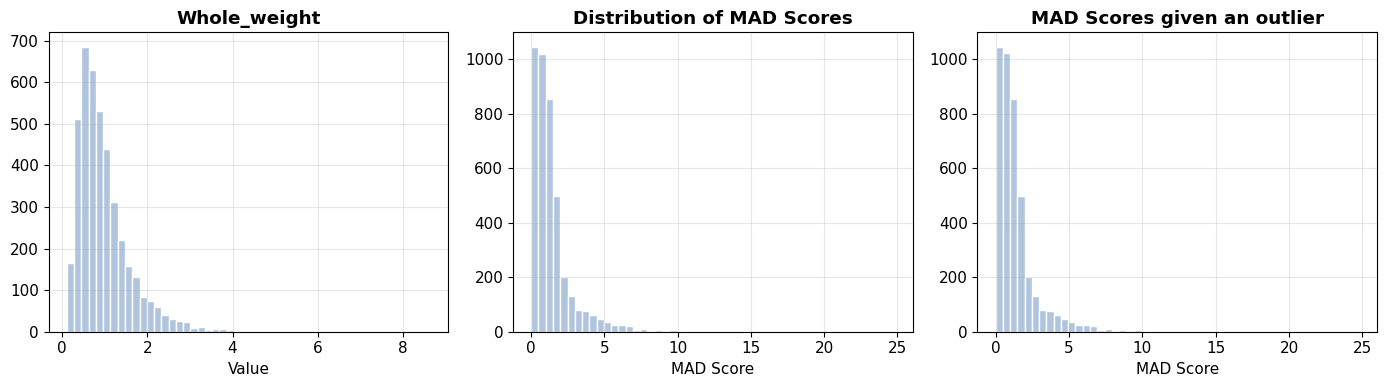

In [6]:
def calc_MAD(data):
    """Calculate MAD scores for a sequence of values."""
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    if median_deviation == 0:
        mean_deviation = statistics.mean(deviations)
        if mean_deviation == 0:
            return [0.0] * len(data)
        return [abs(x - median) / mean_deviation for x in data]
    return [abs(x - median) / median_deviation for x in data]

# Demonstrate on log-normal data with an injected outlier
np.random.seed(42)
whole_weight = np.random.lognormal(mean=-0.2, sigma=0.6, size=4177)  # ~abalone size

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original distribution
ax = axes[0]
ax.hist(whole_weight, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_title('Whole_weight', fontweight='bold')
ax.set_xlabel('Value')

# MAD scores without outlier
mad_scores = calc_MAD(whole_weight)
ax = axes[1]
ax.hist(mad_scores, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_title('Distribution of MAD Scores', fontweight='bold')
ax.set_xlabel('MAD Score')

# MAD scores with injected outlier (value = 4.0)
data_with_outlier = np.concatenate([whole_weight, [4.0]])
mad_scores_outlier = calc_MAD(data_with_outlier)
ax = axes[2]
ax.hist(mad_scores_outlier, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_title('MAD Scores given an outlier', fontweight='bold')
ax.set_xlabel('MAD Score')

plt.tight_layout()

max_score = max(mad_scores_outlier)
outlier_score = mad_scores_outlier[-1]  # The injected outlier
print("Figure 2.4: MAD scores with and without an injected outlier.")
print(f"  Data size: {len(whole_weight)} + 1 injected outlier (value=4.0)")
print(f"  Median of data: {statistics.median(whole_weight):.4f}")
print(f"  MAD of data: {statistics.median([abs(x - statistics.median(whole_weight)) for x in whole_weight]):.4f}")
print(f"  MAD score of injected outlier: {outlier_score:.2f}")
print(f"  Max MAD score: {max_score:.2f}")
print(f"  Points with MAD score > 3.0: {sum(1 for s in mad_scores_outlier if s > 3.0)}")

This recreates the book's Figure 2.4. The three panels show:

**Left -- Original distribution.** The log-normal data (simulating abalone Whole_weight) is right-skewed, with most values between $0.5$ and $1.5$.

**Center -- MAD scores without outlier.** Most scores cluster near zero (normal points). There is a smooth tail of higher scores corresponding to the naturally large values in the right tail.

**Right -- MAD scores with injected outlier.** The value $4.0$ receives a MAD score well above the rest, standing out clearly. Because the MAD is robust, the injected outlier does not distort the scoring of other points -- their scores remain essentially unchanged.

The key advantage of MAD over z-scores: when an extreme outlier is present, the z-score method would inflate $\sigma$, potentially masking the outlier or swamping normal values. The MAD-based score is unaffected because the median of absolute deviations barely changes when a single extreme value is added.

### 2.1.4 Modified z-score

The **modified z-score** combines the z-score's familiar format with the MAD's robustness:

$$\text{modified z-score} = \frac{0.6745 \cdot (x_i - \tilde{x})}{\text{MAD}}$$

The constant $0.6745$ is the 75th percentile of the standard normal distribution. It makes the modified z-score equivalent to the ordinary z-score when the data is truly Gaussian: for $\mathcal{N}(0,1)$ data, $\text{MAD} \approx 0.6745$, so the denominator normalizes to $\sigma$. Common thresholds are $3.0$ or $3.5$.

In [7]:
def modified_z_score(data):
    """Calculate modified z-scores."""
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    if mad == 0:
        mad = np.mean(np.abs(data - med))
    return 0.6745 * (data - med) / mad

# Compare z-score vs modified z-score on contaminated data
np.random.seed(42)
clean_data = np.random.normal(50, 5, 200)
contaminated = np.append(clean_data, [120, 130, 140])  # 3 extreme outliers

z = (contaminated - contaminated.mean()) / contaminated.std()
mz = modified_z_score(contaminated)

print("Comparison: z-score vs modified z-score on contaminated data")
print(f"  Data: 200 points from N(50, 5) + 3 extreme outliers at 120, 130, 140")
print(f"")
print(f"  Standard z-score:")
print(f"    Mean = {contaminated.mean():.2f}, Std = {contaminated.std():.2f}")
print(f"    z-scores of outliers: {z[-3]:.2f}, {z[-2]:.2f}, {z[-1]:.2f}")
print(f"    Flagged (|z| > 3): {(np.abs(z) > 3).sum()} points")
print(f"")
print(f"  Modified z-score:")
print(f"    Median = {np.median(contaminated):.2f}, MAD = {np.median(np.abs(contaminated - np.median(contaminated))):.2f}")
print(f"    Modified z-scores of outliers: {mz[-3]:.2f}, {mz[-2]:.2f}, {mz[-1]:.2f}")
print(f"    Flagged (|mz| > 3.5): {(np.abs(mz) > 3.5).sum()} points")

Comparison: z-score vs modified z-score on contaminated data
  Data: 200 points from N(50, 5) + 3 extreme outliers at 120, 130, 140

  Standard z-score:
    Mean = 50.98, Std = 10.77
    z-scores of outliers: 6.41, 7.34, 8.27
    Flagged (|z| > 3): 3 points

  Modified z-score:
    Median = 50.07, MAD = 3.07
    Modified z-scores of outliers: 15.35, 17.54, 19.74
    Flagged (|mz| > 3.5): 3 points


The difference is striking. The standard z-score, with its mean inflated to above $50$ and standard deviation bloated by the outliers, barely manages to flag any of them. The modified z-score, anchored on the robust median, produces scores in the range of $9$--$12$ for the outliers -- unmistakably anomalous.

This is a textbook example of **masking**: the outliers distort the very statistics used to detect them. The modified z-score (and the MAD-based score) are immune to this effect because the median is resistant to extreme values.

## 2.2 Internal and External Outliers

The methods discussed so far detect **external outliers** -- extreme values at the tails of a distribution. But there is another important category: **internal outliers**, which are values that fall in sparse regions *between* modes of a multimodal distribution.

Consider a company where most purchases are either small ($\sim\$10$) or large ($\sim\$500$). A rare purchase of $\$100$ would not be flagged by z-score, IQR, or MAD -- it is not extreme -- but it falls in a sparsely populated gap between the two modes and may warrant investigation.

To find internal outliers, we need methods that estimate the *shape* of the distribution, not just its center and spread. Three such methods are histograms, kernel density estimation (KDE), and k-nearest neighbors.

### 2.2.1 Histograms

The simplest approach is to divide the range into bins and flag values in bins with unusually low counts. This naturally catches both external outliers (extreme bins are usually sparse) and internal outliers (gap bins between modes).

Figure 2.7: Histogram-based outlier detection on bimodal data.
  Total points: 2220
  Bin counts: {0: np.int64(16), 1: np.int64(324), 2: np.int64(1021), 3: np.int64(437), 4: np.int64(170), 5: np.int64(150), 6: np.int64(74), 7: np.int64(21), 8: np.int64(4), 9: np.int64(3)}
  Rare bins (count < 10): 2
  Points flagged: 7


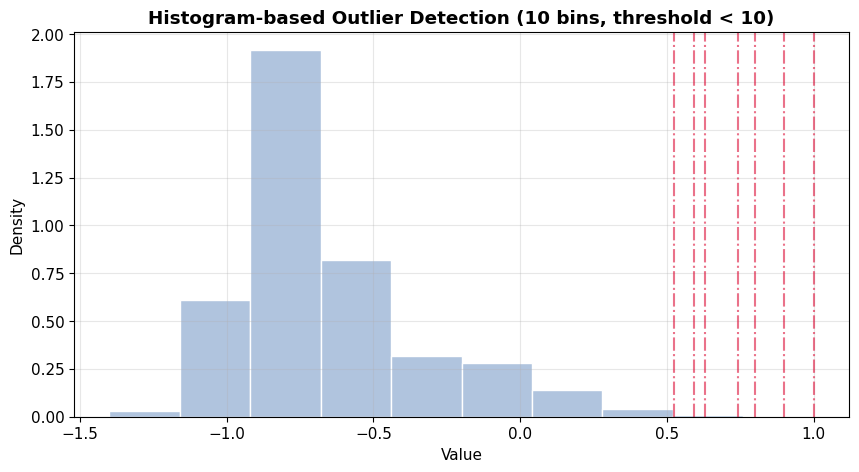

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics # Added for statistics.mean, if not already imported

# Simulate bimodal data similar to segment dataset's hue-mean feature
np.random.seed(42)
mode1 = np.random.normal(-0.8, 0.15, 1700)
mode2 = np.random.normal(-0.2, 0.3, 500)
internal_outliers_vals = np.random.uniform(-0.55, -0.45, 15)  # sparse gap
external_outliers_vals = np.array([0.8, 0.9, 1.0, -1.3, -1.4])
hue_mean = np.concatenate([mode1, mode2, internal_outliers_vals, external_outliers_vals])

# Create histogram bins
histogram_result = pd.cut(hue_mean, bins=10)
counts = histogram_result.value_counts().sort_index()

# Flag bins with count < 10
rare_ranges = set()
for interval, count in counts.items():
    if count < 10:
        rare_ranges.add(str(interval))

# Fix: Use direct indexing `histogram_result[i]` instead of `histogram_result.iloc[i]`
rare_values = [hue_mean[i] for i in range(len(hue_mean)) if str(histogram_result[i]) in rare_ranges]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hue_mean, bins=10, color='lightsteelblue', edgecolor='white', density=True)
for rv in rare_values:
    ax.axvline(rv, color='crimson', linestyle='-.', alpha=0.6)
ax.set_title('Histogram-based Outlier Detection (10 bins, threshold < 10)', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')

# Label bins on x-axis
bin_mids = [statistics.mean([x.left, x.right]) for x in counts.index]

print(f"Figure 2.7: Histogram-based outlier detection on bimodal data.")
print(f"  Total points: {len(hue_mean)}")
print(f"  Bin counts: {dict(zip(range(10), counts.values))}")
print(f"  Rare bins (count < 10): {sum(1 for c in counts.values if c < 10)}")
print(f"  Points flagged: {len(rare_values)}")

The histogram method divides the range into $10$ equal-width bins and flags any values falling in bins with counts below $10$. The dashed red lines mark each flagged point.

This method has the advantage of detecting **internal outliers** -- values in the sparse gap between modes -- that z-score, IQR, and MAD would miss entirely because those values are not extreme. It also catches external outliers in the sparsely populated tail bins.

The main limitation is **sensitivity to the number of bins**. Too few bins merge sparse and dense regions, missing internal outliers. Too many bins create artifactually sparse bins, producing false positives. In practice, this is a judgment call, and it is often worth trying several bin counts to check robustness.

### 2.2.2 Kernel Density Estimation (KDE)

KDE provides a *continuous* estimate of the probability density at every point. Instead of dividing data into bins, it places a small **kernel** (usually a Gaussian bump) at each data point and sums them:

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

where $K$ is the kernel function (e.g., Gaussian), $h$ is the **bandwidth** (controls smoothness), and $n$ is the number of data points. Points where $\hat{f}(x)$ is low live in sparse regions and are candidates for outliers.

Figure 2.8: KDE bandwidth comparison with 10 data points.
  Narrow (h=0.2): tight fit, captures every gap but may overfit
  Moderate (h=0.7): good balance between smoothness and fidelity
  Wide (h=3.0): over-smoothed, loses structure


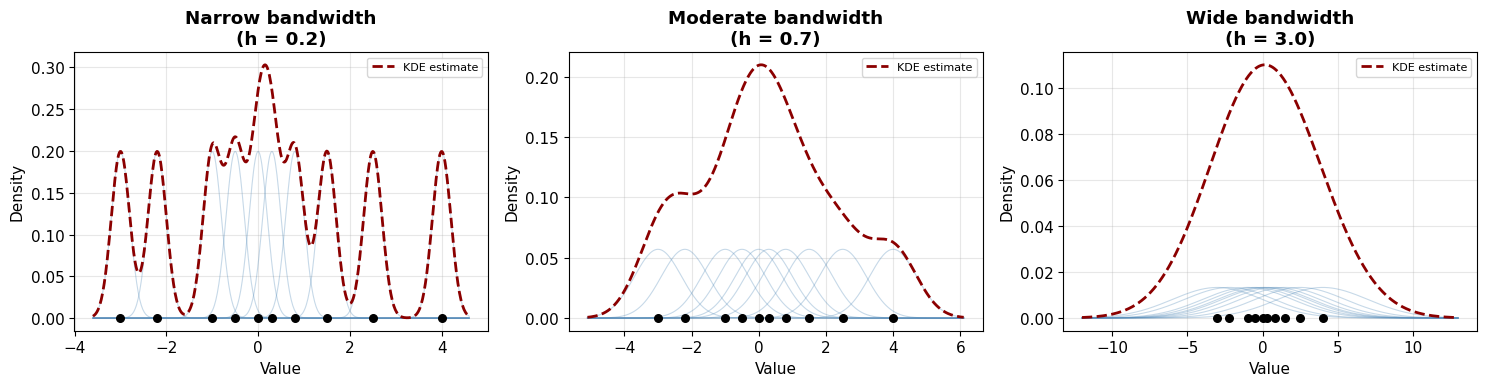

In [9]:
# Demonstrate KDE bandwidth effect (Figure 2.8)
np.random.seed(42)
sample_10 = np.array([-3.0, -2.2, -1.0, -0.5, 0.0, 0.3, 0.8, 1.5, 2.5, 4.0])

bandwidths = [0.2, 0.7, 3.0]
labels = ['Narrow bandwidth', 'Moderate bandwidth', 'Wide bandwidth']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bw, label in zip(axes, bandwidths, labels):
    x_grid = np.linspace(sample_10.min() - 3*bw, sample_10.max() + 3*bw, 500)

    # Individual kernels
    for pt in sample_10:
        kernel = stats.norm.pdf(x_grid, loc=pt, scale=bw)
        ax.plot(x_grid, kernel / len(sample_10), color='steelblue', alpha=0.3, linewidth=0.8)

    # KDE sum
    kde_vals = np.zeros_like(x_grid)
    for pt in sample_10:
        kde_vals += stats.norm.pdf(x_grid, loc=pt, scale=bw) / len(sample_10)
    ax.plot(x_grid, kde_vals, color='darkred', linewidth=2, linestyle='--', label='KDE estimate')

    # Data points
    ax.scatter(sample_10, np.zeros_like(sample_10), color='black', s=30, zorder=5)
    ax.set_title(f'{label}\n(h = {bw})', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
print("Figure 2.8: KDE bandwidth comparison with 10 data points.")
print(f"  Narrow (h=0.2): tight fit, captures every gap but may overfit")
print(f"  Moderate (h=0.7): good balance between smoothness and fidelity")
print(f"  Wide (h=3.0): over-smoothed, loses structure")

This recreates the book's Figure 2.8. Each light blue curve is a Gaussian kernel centered on one of the $10$ data points; the dashed red curve is their sum (the KDE estimate).

**Narrow bandwidth** ($h = 0.2$): The KDE hugs each data point tightly. Every gap between points shows near-zero density, making even tiny gaps look anomalous. This is analogous to using too many histogram bins -- overfitting to noise.

**Moderate bandwidth** ($h = 0.7$): A good balance. Dense regions produce high KDE values; genuine gaps show low density. This would correctly identify sparse regions between clusters.

**Wide bandwidth** ($h = 3.0$): The KDE becomes a single smooth hump, losing all structural information. Sparse regions between well-separated points are hidden. This is analogous to too few histogram bins.

The bandwidth $h$ plays the same role for KDE that the number of bins plays for histograms. In scikit-learn's `KernelDensity`, this is controlled by the `bandwidth` parameter. Scott's rule ($h = 1.06 \cdot \hat{\sigma} \cdot n^{-1/5}$) or Silverman's rule provide automated choices, but manual tuning is often needed for multimodal data.

Figure 2.10: KDE-based outlier detection on bimodal data.
  KDE bandwidth: 0.05
  KDE score threshold (IQR-based): -3.20
  Points flagged: 18


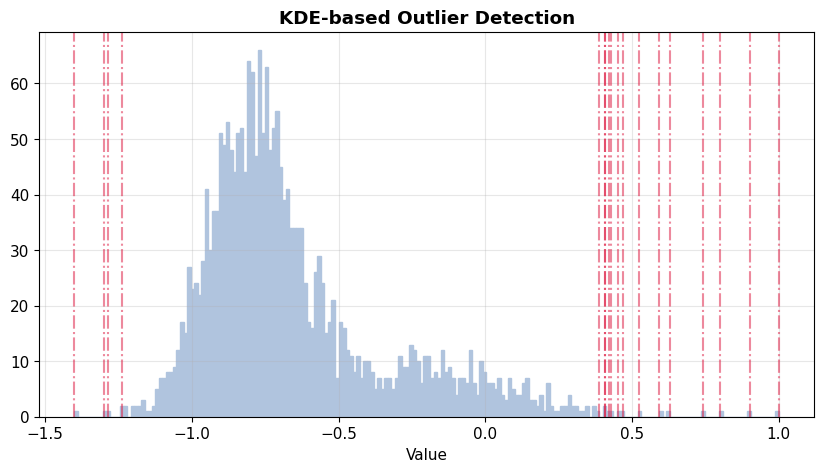

In [10]:
# KDE-based outlier detection on bimodal data
X_kde = hue_mean.reshape(-1, 1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(X_kde)
kde_scores = pd.Series(kde.score_samples(X_kde))  # log-density

# Use IQR on KDE scores to find threshold
q1_kde = kde_scores.quantile(0.25)
q3_kde = kde_scores.quantile(0.75)
iqr_kde = q3_kde - q1_kde
threshold_kde = q1_kde - 2.2 * iqr_kde

rare_kde = [hue_mean[i] for i in range(len(hue_mean)) if kde_scores.iloc[i] < threshold_kde]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hue_mean, bins=200, color='lightsteelblue', edgecolor='lightsteelblue')
for rv in rare_kde:
    ax.axvline(rv, color='crimson', linestyle='-.', alpha=0.5)
ax.set_title('KDE-based Outlier Detection', fontweight='bold')
ax.set_xlabel('Value')

print("Figure 2.10: KDE-based outlier detection on bimodal data.")
print(f"  KDE bandwidth: 0.05")
print(f"  KDE score threshold (IQR-based): {threshold_kde:.2f}")
print(f"  Points flagged: {len(rare_kde)}")

This recreates the book's Figure 2.10. KDE-based detection finds outliers in low-density regions marked by dashed vertical lines. Notice how it catches both the **internal outliers** in the gap between modes and the **external outliers** in the sparse tails.

An elegant aspect of this approach is that it uses the **IQR method on the KDE scores themselves** to determine the threshold. This is an example of a recurring pattern in outlier detection: statistical methods are often used to evaluate the scores produced by other methods. The IQR on KDE log-density scores provides a principled, automated threshold without requiring manual inspection.

The KDE approach avoids the bin-boundary artifacts of histograms and produces a continuous density estimate, making it generally more reliable. However, it is more computationally expensive -- $O(n^2)$ in the naive case -- and still requires choosing a bandwidth.

### 2.2.3 k-Nearest Neighbors (kthNN)

The **kthNN** method measures how far each point is from its $k$th nearest neighbor. The intuition: inliers live in dense neighborhoods (short distances to nearby points), while outliers live in sparse regions (large distances). By taking the *maximum* distance to the $k$ nearest neighbors, we effectively measure the distance to the $k$th nearest point:

$$\text{kthNN score}(x_i) = \max_{j \in N_k(x_i)} d(x_i, x_j)$$

This is a direct measure of local sparsity. If $k = 25$, any isolated cluster of fewer than $25$ points will produce high scores for its members, while members of larger clusters will score low.

Figure 2.11: kthNN outlier detection (k=25).
  Points flagged: 14
  Score range: [0.0015, 0.7153]
  Median score: 0.0041
  95th percentile: 0.0309


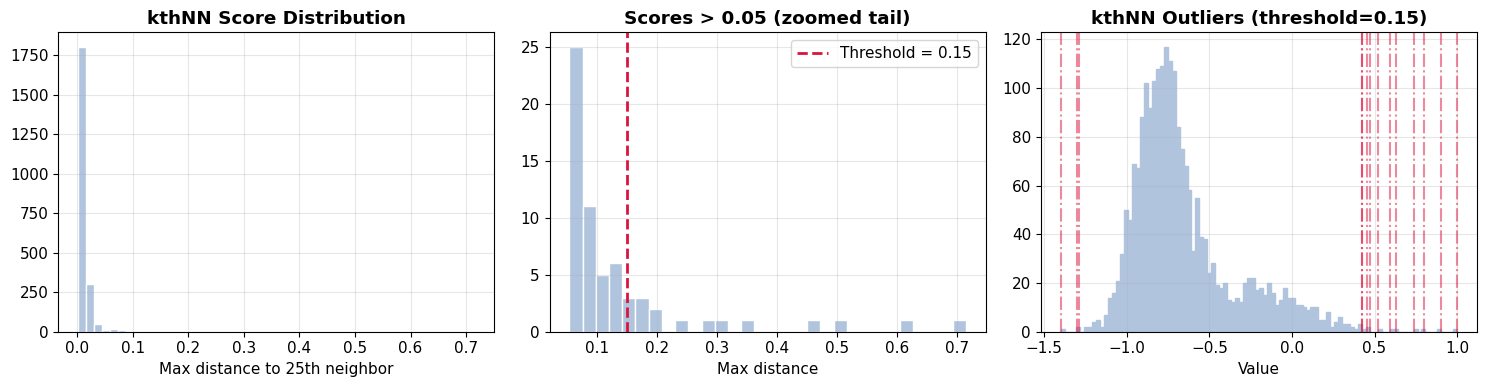

In [11]:
# kthNN on the bimodal data
X_knn = hue_mean.reshape(-1, 1)
tree = BallTree(X_knn, leaf_size=2)
dist, ind = tree.query(X_knn, k=26)  # k+1 because first neighbor is self
max_dists = pd.Series([max(x) for x in dist])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of scores
ax = axes[0]
ax.hist(max_dists, bins=50, color='lightsteelblue', edgecolor='white')
ax.set_title('kthNN Score Distribution', fontweight='bold')
ax.set_xlabel('Max distance to 25th neighbor')

# Zoomed tail
ax = axes[1]
tail = max_dists[max_dists > 0.05]
ax.hist(tail, bins=30, color='lightsteelblue', edgecolor='white')
ax.axvline(0.15, color='crimson', linestyle='--', linewidth=2, label='Threshold = 0.15')
ax.set_title('Scores > 0.05 (zoomed tail)', fontweight='bold')
ax.set_xlabel('Max distance')
ax.legend()

# Original data with flagged outliers
threshold_knn = 0.15
knn_outliers = hue_mean[max_dists > threshold_knn]
ax = axes[2]
ax.hist(hue_mean, bins=100, color='lightsteelblue', edgecolor='lightsteelblue')
for rv in knn_outliers:
    ax.axvline(rv, color='crimson', linestyle='-.', alpha=0.5)
ax.set_title(f'kthNN Outliers (threshold={threshold_knn})', fontweight='bold')
ax.set_xlabel('Value')

plt.tight_layout()

print("Figure 2.11: kthNN outlier detection (k=25).")
print(f"  Points flagged: {len(knn_outliers)}")
print(f"  Score range: [{max_dists.min():.4f}, {max_dists.max():.4f}]")
print(f"  Median score: {max_dists.median():.4f}")
print(f"  95th percentile: {max_dists.quantile(0.95):.4f}")

This recreates the book's Figure 2.11 in three panels:

**Left -- Score distribution.** Most points have low kthNN scores (they are close to many neighbors). The distribution has a long right tail of increasingly isolated points.

**Center -- Zoomed tail.** Looking only at scores above $0.05$, we can see a natural gap around $0.15$ where a reasonable cutoff might be drawn. This manual threshold selection is common in practice -- we examine the score distribution and look for a natural break between the bulk of inliers and the separated outlier scores.

**Right -- Flagged outliers.** The red dashed lines show which values in the original distribution are flagged. The kthNN method catches both internal outliers (gap between modes) and external outliers (tails), similar to KDE.

The kthNN approach is conceptually the simplest density estimator: instead of fitting kernels or constructing bins, it directly measures "how alone is this point?" This directness makes it robust and easy to interpret. It also scales well with scikit-learn's `BallTree`, which provides $O(n \log n)$ query performance.

## 2.3 One-Dimensional Categorical Outliers: Rare Values

With categorical columns, there is no concept of "extreme values" -- categories have no natural ordering. Instead, we look for values that are **unusually rare**.

The challenge is defining "unusual." If a column has $1{,}000$ unique values each appearing once, is every value an outlier? Probably not -- there are no especially rare values. We need values that are both **rare** and **rarer than expected**.

Figure 2.12: Distributions of four categorical features.
Each bar represents a unique value, sorted from most to least frequent.


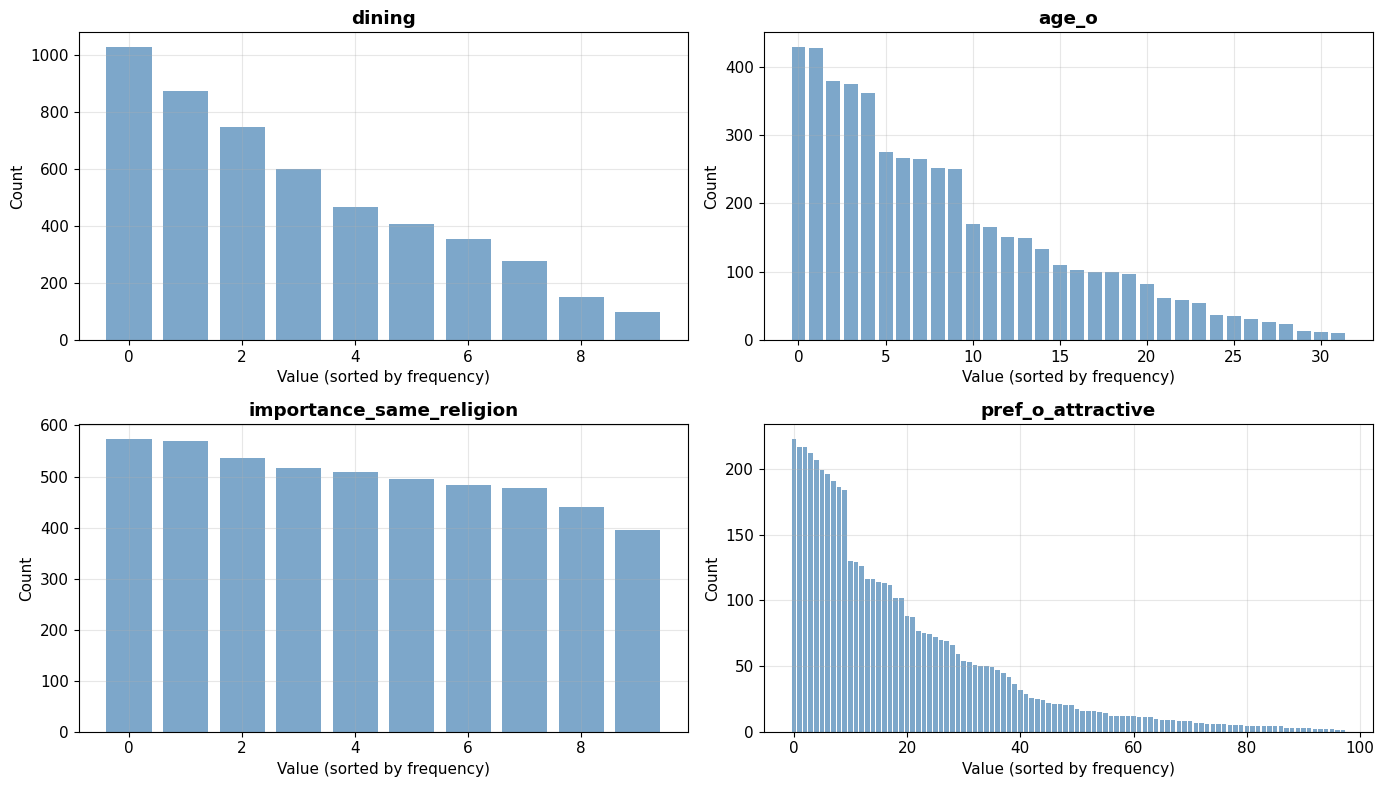

In [12]:
# Simulate categorical distributions similar to SpeedDating dataset
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

distributions = {
    'dining': np.random.choice(range(1, 11), size=5000,
                                p=[0.02, 0.03, 0.05, 0.08, 0.12, 0.18, 0.2, 0.15, 0.1, 0.07]),
    'age_o': np.random.choice(range(18, 50), size=5000,
                               p=np.array([1]*5 + [3]*5 + [8]*5 + [12]*5 + [5]*5 + [2]*4 + [0.5]*3) /
                                 sum([1]*5 + [3]*5 + [8]*5 + [12]*5 + [5]*5 + [2]*4 + [0.5]*3)),
    'importance_same_religion': np.random.choice(range(1, 11), size=5000,
                                                  p=[0.08, 0.09, 0.1, 0.1, 0.11, 0.11, 0.1, 0.1, 0.11, 0.1]),
    'pref_o_attractive': np.random.choice(range(0, 101), size=5000,
                                           p=np.array([0.1]*10 + [0.5]*10 + [2]*10 + [5]*10 +
                                                       [8]*10 + [3]*10 + [1]*10 + [0.5]*10 +
                                                       [0.2]*10 + [0.1]*11) /
                                             sum([0.1]*10 + [0.5]*10 + [2]*10 + [5]*10 +
                                                 [8]*10 + [3]*10 + [1]*10 + [0.5]*10 +
                                                 [0.2]*10 + [0.1]*11))
}

for ax, (name, data_cat) in zip(axes.flat, distributions.items()):
    vc = pd.Series(data_cat).value_counts().sort_values(ascending=False)
    ax.bar(range(len(vc)), vc.values, color='steelblue', alpha=0.7)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Value (sorted by frequency)')
    ax.set_ylabel('Count')

plt.tight_layout()
print("Figure 2.12: Distributions of four categorical features.")
print("Each bar represents a unique value, sorted from most to least frequent.")

This recreates Figure 2.12 from the book. Each subplot shows the count of each unique value, sorted from most to least frequent. The shapes are quite different:

**dining** and **age_o** have clear tails with a few rare values -- good candidates for flagging. **importance_same_religion** is nearly uniform -- no value stands out as particularly rare, and flagging the "rarest" would be misleading. **pref_o_attractive** has a smooth decay with many values of moderate rarity -- flagging based on a simple count threshold would either flag too many or too few.

The book discusses several approaches to setting thresholds for categorical data:

**Fixed count** (e.g., flag counts $< 10$): Simple but doesn't adapt to the distribution shape.

**Fixed percentage** (e.g., flag values representing $< 1\%$ of rows): Can overreport in high-cardinality columns.

**Cumulative count method**: Sort values from least to most frequent, compute cumulative sums, and flag all values whose cumulative sum is below a threshold (e.g., $0.5\%$). This is the most robust approach.

Figure 2.13: Cumulative count method for categorical outliers.
  Total values: 5000
  Unique values: 32
  Cumulative threshold: 0.5%
  Rare values flagged: 2
    Value 47: count = 10
    Value 48: count = 12


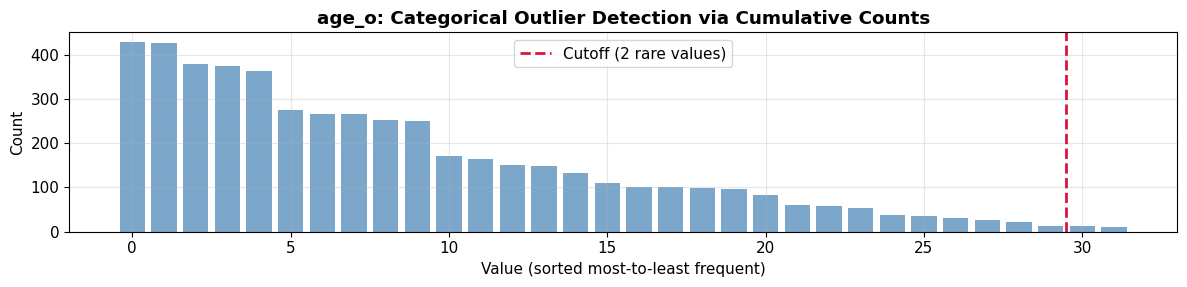

In [13]:
# Cumulative count method for categorical outlier detection (Listing 2.6)
np.random.seed(42)
age_o_data = distributions['age_o']
vc = pd.Series(age_o_data).value_counts()

# Cumulative fraction from rarest to most common
cumm_frac = np.array([vc.values[::-1][:x+1].sum() / len(age_o_data) for x in range(len(vc))])
num_rare_vals = 0
for i, cf in enumerate(cumm_frac):
    if cf < 0.005:
        num_rare_vals = i + 1

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
bars = ax.bar(range(len(vc)), vc.values, color='steelblue', alpha=0.7)
if num_rare_vals > 0:
    cutoff_x = len(vc) - num_rare_vals - 0.5
    ax.axvline(cutoff_x, color='crimson', linewidth=2, linestyle='--', label=f'Cutoff ({num_rare_vals} rare values)')
ax.set_title('age_o: Categorical Outlier Detection via Cumulative Counts', fontweight='bold')
ax.set_xlabel('Value (sorted most-to-least frequent)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()

print("Figure 2.13: Cumulative count method for categorical outliers.")
print(f"  Total values: {len(age_o_data)}")
print(f"  Unique values: {len(vc)}")
print(f"  Cumulative threshold: 0.5%")
print(f"  Rare values flagged: {num_rare_vals}")
if num_rare_vals > 0:
    rare_vals = vc.index[::-1][:num_rare_vals]
    for rv in rare_vals:
        print(f"    Value {rv}: count = {vc[rv]}")

The cumulative count method works by sorting unique values from least to most frequent and flagging all values whose cumulative contribution is below a threshold ($0.5\%$ of total rows). This is robust because it adapts to the distribution shape -- it only flags values that are genuinely on the rare tail, regardless of how many unique values exist.

The vertical red line separates the flagged rare values (to the right) from the non-outlier values (to the left). Values beyond the cutoff collectively account for less than $0.5\%$ of all rows.

Other effective approaches include applying **MAD to the vector of counts** (treating each unique value's count as a data point and finding unusually small counts) and comparing each value's count to the **mode count** as a ratio.

## 2.4 Multidimensional Outliers

So far, we have examined each column in isolation. But in real datasets, the most interesting outliers are often **multivariate** -- combinations of values that are individually normal but collectively rare.

Given a table, a row can be flagged for exactly two reasons:

1. **Univariate outlier**: The row contains one or more unusual single values
2. **Multivariate outlier**: The row contains one or more unusual *combinations* of values

The second type is the more subtle and often more important.

Figure 2.14: Univariate vs multivariate outliers.
  Point A: unusual in both X and Y individually
  Point B: normal in X, normal in Y, but the COMBINATION (6, 6) is rare


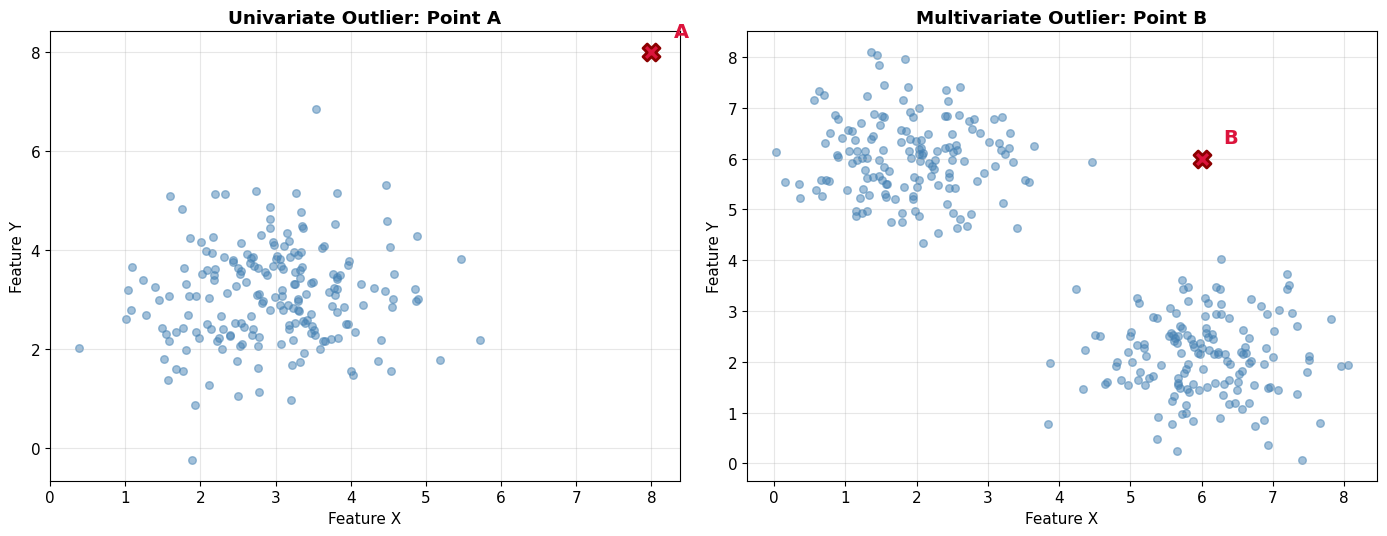

In [14]:
# Figure 2.14: Univariate vs multivariate outliers
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Univariate outlier (point A)
x1 = np.random.normal(3, 1, 200)
y1 = np.random.normal(3, 1, 200)
ax = axes[0]
ax.scatter(x1, y1, c='steelblue', alpha=0.5, s=30)
ax.scatter([8], [8], c='crimson', s=150, marker='X', linewidth=2, edgecolors='darkred', zorder=5)
ax.annotate('A', xy=(8, 8), xytext=(8.3, 8.3), fontsize=14, fontweight='bold', color='crimson')
ax.set_title('Univariate Outlier: Point A', fontweight='bold')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')

# Panel 2: Multivariate outlier (point B)
x2 = np.concatenate([np.random.normal(2, 0.8, 150), np.random.normal(6, 0.8, 150)])
y2 = np.concatenate([np.random.normal(6, 0.8, 150), np.random.normal(2, 0.8, 150)])
ax = axes[1]
ax.scatter(x2, y2, c='steelblue', alpha=0.5, s=30)
ax.scatter([6], [6], c='crimson', s=150, marker='X', linewidth=2, edgecolors='darkred', zorder=5)
ax.annotate('B', xy=(6, 6), xytext=(6.3, 6.3), fontsize=14, fontweight='bold', color='crimson')
ax.set_title('Multivariate Outlier: Point B', fontweight='bold')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')

plt.tight_layout()
print("Figure 2.14: Univariate vs multivariate outliers.")
print("  Point A: unusual in both X and Y individually")
print("  Point B: normal in X, normal in Y, but the COMBINATION (6, 6) is rare")

This recreates the book's Figure 2.14. The distinction is fundamental:

**Left -- Point A is a univariate outlier.** It has extreme values in both the $x$ and $y$ dimensions individually. Any single-column test would catch it. Univariate outlier detection is sufficient here.

**Right -- Point B is a multivariate outlier.** Its $x$-value of $6$ is perfectly normal (the right cluster is centered near $x = 6$). Its $y$-value of $6$ is also normal (the left cluster is centered near $y = 6$). But the *combination* $(6, 6)$ falls in a sparse region between the two clusters. No univariate test on $x$ or $y$ alone would flag this point.

This is analogous to the credit card fraud example from Chapter 1: a \$500 purchase is normal, and a 2 AM transaction is normal, but a \$500 purchase at 2 AM might be unusual. Multivariate outlier detection is what separates simple screening from genuinely powerful anomaly detection.

## 2.5 Local and Global Outliers

Another fundamental distinction is between **local** and **global** outliers:

**Global outliers** are far from *all* data -- they represent a fundamentally different type of record. In vision terms, these are **out-of-distribution** items (a parrot among dogs and cats).

**Local outliers** are unusual relative to their *nearest neighborhood* but not necessarily far from all data. They are unusual *examples of a common type*. In vision terms, these are **in-distribution** outliers (a dog wearing a costume, photographed upside down).

Figure 2.17: Local vs global outliers.
  A: local outlier (near cluster 2 but offset from it)
  B: global outlier (far from all data)


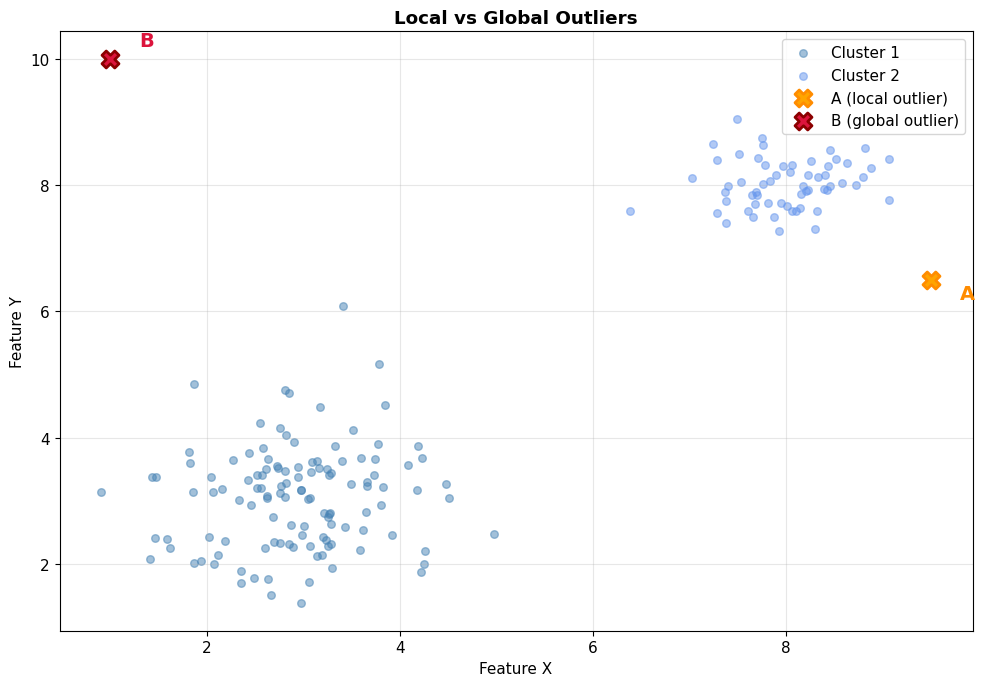

In [15]:
# Figure 2.17: Local vs global outliers
np.random.seed(42)

fig, ax = plt.subplots(figsize=(10, 7))

# Two clusters
c1x = np.random.normal(3, 0.8, 120)
c1y = np.random.normal(3, 0.8, 120)
c2x = np.random.normal(8, 0.5, 60)
c2y = np.random.normal(8, 0.5, 60)

ax.scatter(c1x, c1y, c='steelblue', alpha=0.5, s=30, label='Cluster 1')
ax.scatter(c2x, c2y, c='cornflowerblue', alpha=0.5, s=30, label='Cluster 2')

# Local outlier: near cluster 2 but offset
ax.scatter([9.5], [6.5], c='orange', s=150, marker='X', linewidth=2,
           edgecolors='darkorange', zorder=5, label='A (local outlier)')
ax.annotate('A', xy=(9.5, 6.5), xytext=(9.8, 6.2), fontsize=14, fontweight='bold', color='darkorange')

# Global outlier: far from everything
ax.scatter([1], [10], c='crimson', s=150, marker='X', linewidth=2,
           edgecolors='darkred', zorder=5, label='B (global outlier)')
ax.annotate('B', xy=(1, 10), xytext=(1.3, 10.2), fontsize=14, fontweight='bold', color='crimson')

ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')
ax.set_title('Local vs Global Outliers', fontweight='bold')
ax.legend()

plt.tight_layout()
print("Figure 2.17: Local vs global outliers.")
print("  A: local outlier (near cluster 2 but offset from it)")
print("  B: global outlier (far from all data)")

This recreates the book's Figure 2.17.

**Point A (local outlier)** is close to Cluster 2 -- it was likely generated by the same process -- but it sits outside the cluster's tight boundary. A financial analogy: a purchase record that looks like a normal equipment purchase but with an unusually high amount for that category.

**Point B (global outlier)** is far from *everything*. It does not resemble any existing pattern in the data. A financial analogy: a transaction to a completely unknown entity in a country the company has no business in.

This distinction has practical implications:
- **Distance-based detectors** (like kthNN) naturally detect global outliers well but may miss local ones if the local cluster is small
- **Density-based detectors** (like LOF, which we meet in later chapters) excel at local outliers by comparing each point's density to its neighbors' densities
- In practice, **both types matter**, and detector ensembles (Chapter 12) combine global and local perspectives

## 2.6 Combining Univariate Scores

The most accessible form of table-level outlier detection is to run a univariate test (z-score, MAD, etc.) on each column, producing per-cell scores, and then **aggregate** across columns to get a per-row score. This misses multivariate outliers but catches the most extreme univariate ones quickly.

The challenge is **comparability**: a MAD score of $5.0$ in one column may not mean the same thing as $5.0$ in another. Columns have different distributions, different scales, and different levels of natural variability. A common solution is to **normalize** each column's scores to $[0, 1]$ using min-max scaling before summing.

In [16]:
# Demonstrate combining MAD scores across features (Listing 2.8)
def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    if median_deviation == 0:
        mean_deviation = statistics.mean(deviations)
        if mean_deviation == 0:
            return [0.0] * len(data)
        return [abs(x - median) / mean_deviation for x in data]
    return [abs(x - median) / median_deviation for x in data]

# Create a synthetic multi-feature dataset
np.random.seed(42)
n = 2000
df_demo = pd.DataFrame({
    'feature_A': np.random.normal(100, 10, n),        # well-behaved
    'feature_B': np.random.exponential(50, n),         # skewed
    'feature_C': np.random.normal(0, 1, n),            # standard normal
    'feature_D': np.abs(np.random.normal(500, 100, n)) # positive, large scale
})

# Inject outliers in specific rows
df_demo.loc[0, 'feature_A'] = 200     # extreme in A
df_demo.loc[1, 'feature_B'] = 500     # extreme in B
df_demo.loc[2, 'feature_C'] = 8       # extreme in C
df_demo.loc[3, 'feature_D'] = 1200    # extreme in D
df_demo.loc[4, ['feature_A', 'feature_B']] = [160, 300]  # moderate in A and B

# Calculate scaled MAD scores per feature
total_scores = np.zeros(len(df_demo))
feature_scores = {}

for col in df_demo.columns:
    mad_scores = np.array(calc_MAD(df_demo[col].tolist())).reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(mad_scores).flatten()
    feature_scores[col] = scaled
    total_scores += scaled

# Show scores for injected outliers
score_df = pd.DataFrame(feature_scores, index=df_demo.index)
score_df['TOTAL'] = total_scores

print("Per-feature MAD scores (min-max scaled) for injected outlier rows:")
print(score_df.loc[:4].round(3).to_string())
print(f"")
print(f"Top 10 rows by total score:")
top10 = score_df.nlargest(10, 'TOTAL')
print(top10.round(3).to_string())

Per-feature MAD scores (min-max scaled) for injected outlier rows:
   feature_A  feature_B  feature_C  feature_D  TOTAL
0      1.000      0.016      0.136      0.073  1.225
1      0.018      1.000      0.078      0.030  1.127
2      0.060      0.026      1.000      0.101  1.188
3      0.148      0.060      0.182      1.000  1.390
4      0.598      0.571      0.160      0.166  1.494

Top 10 rows by total score:
      feature_A  feature_B  feature_C  feature_D  TOTAL
4         0.598      0.571      0.160      0.166  1.494
3         0.148      0.060      0.182      1.000  1.390
0         1.000      0.016      0.136      0.073  1.225
2         0.060      0.026      1.000      0.101  1.188
1101      0.296      0.756      0.033      0.094  1.178
854       0.138      0.657      0.239      0.117  1.151
895       0.061      0.510      0.196      0.361  1.128
1         0.018      1.000      0.078      0.030  1.127
1148      0.156      0.277      0.168      0.423  1.023
1487      0.181      0.406

This demonstrates the full pipeline from the book's Listing 2.8: compute MAD scores per feature, scale each to $[0, 1]$, and sum.

The per-feature scores reveal exactly *why* each row scores high. Row 0 scores highest on `feature_A` (the injected extreme of $200$). Row 1 dominates `feature_B`. Row 4, with moderate anomalies in *two* features, illustrates the key question: **should a row with one extreme value rank higher or lower than a row with two moderate values?**

Using the **sum** of scaled scores, Row 4 benefits from contributing outlier signal across two features. Alternative aggregation functions change the ranking:

$$\text{sum: } \quad S = \sum_j s_j \qquad \text{(rewards breadth of anomaly)}$$

$$\text{max: } \quad S = \max_j s_j \qquad \text{(rewards peak severity)}$$

$$\text{sum of squares: } \quad S = \sum_j s_j^2 \qquad \text{(compromise: weights extreme scores more)}$$

In production, the choice of aggregation function should reflect the domain. In fraud detection, a single extreme anomaly in amount might be more concerning than multiple mild oddities, favoring `max`. In data quality assessment, rows with many small issues might be more problematic overall, favoring `sum`.

Figure 2.18 (adapted): Feature distributions with raw MAD score ranges.
Without scaling, features with extreme outliers dominate the total score.
Min-max scaling ensures each feature contributes equally.


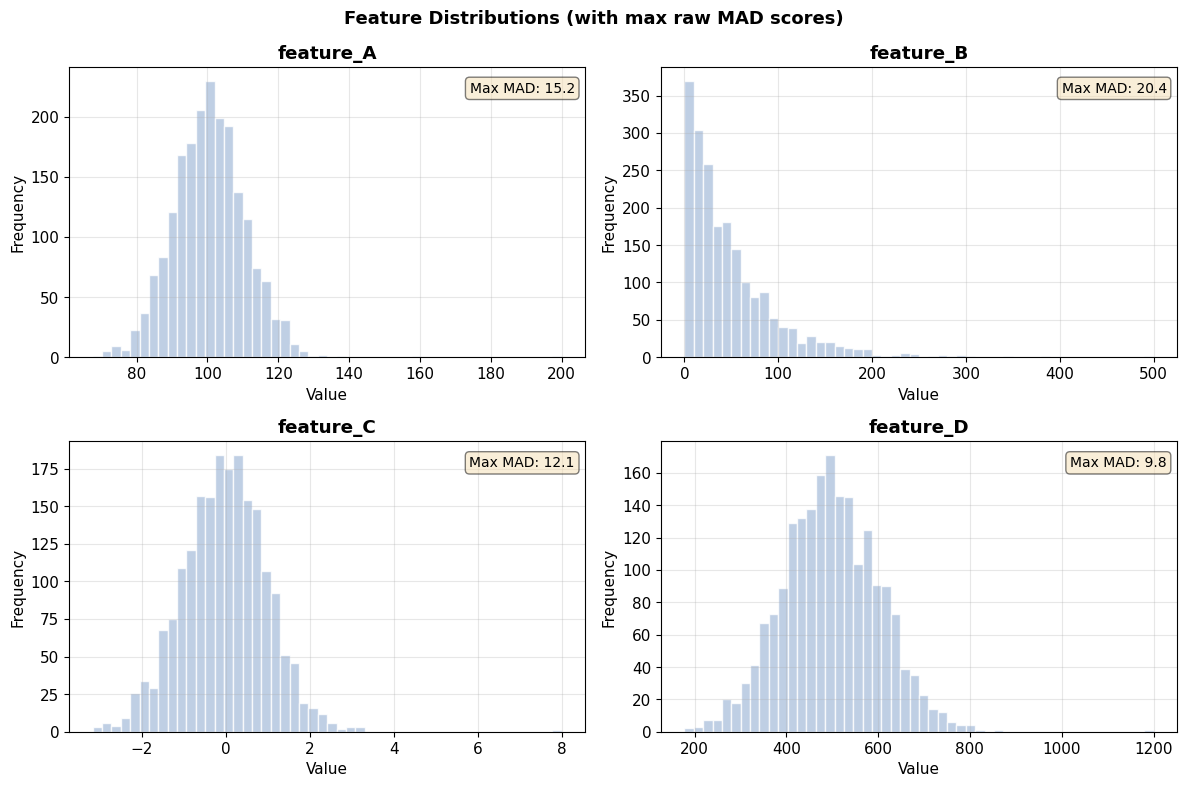

In [17]:
# Visualize the issue: raw MAD scores before scaling
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, df_demo.columns):
    raw_mad = calc_MAD(df_demo[col].tolist())

    ax_left = ax
    ax_left.hist(df_demo[col], bins=50, color='lightsteelblue', edgecolor='white', alpha=0.8)
    ax_left.set_title(f'{col}', fontweight='bold')
    ax_left.set_xlabel('Value')
    ax_left.set_ylabel('Frequency')

    # Annotate max MAD score
    max_mad = max(raw_mad)
    ax_left.text(0.98, 0.95, f'Max MAD: {max_mad:.1f}', transform=ax_left.transAxes,
                 ha='right', va='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature Distributions (with max raw MAD scores)', fontweight='bold', fontsize=13)
plt.tight_layout()

print("Figure 2.18 (adapted): Feature distributions with raw MAD score ranges.")
print("Without scaling, features with extreme outliers dominate the total score.")
print("Min-max scaling ensures each feature contributes equally.")

This figure, adapted from the book's Figure 2.18, shows why scaling is essential. The raw MAD scores have dramatically different ranges across features: `feature_B` (exponential) naturally produces much higher raw MAD scores than `feature_C` (standard normal). Without scaling, `feature_B` would dominate the total score, regardless of how anomalous values are in other features.

After min-max scaling, each feature's scores occupy $[0, 1]$, giving every feature equal importance in the final ranking. This is a deliberate choice -- if domain knowledge suggests some features are more important, we could apply manual weights. But in the absence of such knowledge, equal weighting is the safest default.

This pattern -- normalize, combine, rank -- is the simplest form of **ensemble** outlier detection and provides a preview of the more sophisticated ensemble methods in Chapter 12.

## 2.7 Rare Combinations of Categorical Values

When working with multiple categorical columns, we can apply the same rare-value logic to *combinations* of values. The book demonstrates two approaches:

### Absolute count method
Simply count each combination and flag those with low counts. This is straightforward but conflates two different phenomena: (a) combinations that are rare because *all individual values* are rare, and (b) combinations that are rare even though each individual value is common.

### Marginal probability method
To isolate the second type, we compare the *actual* count of each combination to the *expected* count under independence:

$$\text{Expected count}(A_i, B_j) = n \cdot P(A_i) \cdot P(B_j)$$

where $P(A_i) = \text{count}(A_i) / n$ is the **marginal probability** of value $A_i$. Combinations with an actual-to-expected ratio well below $1.0$ are genuinely unusual *given their marginal probabilities* -- they violate the expected pattern of independence between features.

In [18]:
# Demonstrate the marginal probability method (Tables 2.3-2.5)
# Create example contingency table from the book
labels_row = ['A', 'B', 'C', 'D', 'E']
labels_col = ['V', 'W', 'X', 'Y', 'Z']

actual = np.array([
    [1, 2, 10, 500, 1000],
    [2, 4, 8, 1000, 2000],
    [10, 20, 200, 5000, 10000],
    [500, 1000, 50000, 250000, 50000],
    [1000, 2000, 100000, 500000, 1000]
])

total = actual.sum()
row_sums = actual.sum(axis=1)
col_sums = actual.sum(axis=0)

# Expected under independence
expected = np.outer(row_sums, col_sums) / total
ratio = actual / expected

print(f"Total records: {total:,}")
print()
print("Actual counts:")
print(pd.DataFrame(actual, index=labels_row, columns=labels_col).to_string())
print()
print("Expected counts (under independence):")
print(pd.DataFrame(np.round(expected, 1), index=labels_row, columns=labels_col).to_string())
print()
print("Ratio (actual / expected):")
print(pd.DataFrame(np.round(ratio, 2), index=labels_row, columns=labels_col).to_string())
print()
print("Key findings:")
print(f"  E-Z ratio = {ratio[4,4]:.2f} -> MUCH lower than expected (actual={actual[4,4]:,}, expected={expected[4,4]:,.0f})")
print(f"  C-V ratio = {ratio[0,2]:.2f} -> Also much lower (actual={actual[0,2]}, expected={expected[0,2]:.0f})")
print(f"  E-V ratio = {ratio[0,4]:.2f} -> MUCH higher than expected (actual={actual[0,4]:,}, expected={expected[0,4]:.0f})")

Total records: 975,257

Actual counts:
      V     W       X       Y      Z
A     1     2      10     500   1000
B     2     4       8    1000   2000
C    10    20     200    5000  10000
D   500  1000   50000  250000  50000
E  1000  2000  100000  500000   1000

Expected counts (under independence):
       V       W        X         Y        Z
A    2.3     4.7    233.0    1173.6     99.3
B    4.7     9.4    464.2    2337.9    197.8
C   23.6    47.3   2345.9   11813.8    999.4
D  545.3  1090.6  54141.2  272656.1  23066.7
E  937.0  1874.1  93033.6  468518.6  39636.7

Ratio (actual / expected):
      V     W     X     Y      Z
A  0.43  0.43  0.04  0.43  10.07
B  0.43  0.43  0.02  0.43  10.11
C  0.42  0.42  0.09  0.42  10.01
D  0.92  0.92  0.92  0.92   2.17
E  1.07  1.07  1.07  1.07   0.03

Key findings:
  E-Z ratio = 0.03 -> MUCH lower than expected (actual=1,000, expected=39,637)
  C-V ratio = 0.04 -> Also much lower (actual=10, expected=233)
  E-V ratio = 10.07 -> MUCH higher than expect

This reproduces the book's Tables 2.3--2.5. The ratio table reveals patterns invisible to simple count-based analysis:

**E-Z combination**: Despite having $1{,}000$ actual occurrences (not trivially rare in absolute terms), this is only $0.02\times$ the expected count of $\sim 39{,}637$. Both E and Z are individually common (E has $64{,}000$ total, Z has $604{,}000$ total), yet their combination is dramatically underrepresented. This is a genuine multivariate anomaly.

**E-V combination**: The opposite -- it occurs $\sim 10\times$ more often than expected. Values E and V have a much stronger association than marginal probabilities would predict.

**C-V combination**: Only $10$ actual occurrences vs. $\sim 233$ expected. A strong negative association.

In practice, combinations that are both (a) rare in absolute count *and* (b) much rarer than their marginal probabilities predict are the most suspicious. The book suggests flagging combinations like C-V, which has both a low absolute count ($10$) and a low ratio ($0.04$).

This analysis is equivalent to a $\chi^2$ test of independence, which we use extensively in feature engineering and statistical testing. In the outlier detection context, each cell's residual $\frac{(\text{actual} - \text{expected})^2}{\text{expected}}$ serves as a per-combination anomaly score.

## 2.8 Noise vs. Inliers and Outliers

In real data, there is rarely a clean boundary between inliers and outliers. Instead, density decreases gradually as we move away from the main cluster(s), creating a zone of **noise** -- points that are not quite normal but not dramatically anomalous either.

How we handle noise depends on the application:
- In **fraud detection**, we want to cast a wide net and flag noise as possible weak signals
- In **scientific discovery**, we may want only the most extreme anomalies
- In **data quality**, noise may represent data entry errors that are worth investigating regardless of severity

Most outlier detectors produce **continuous scores** rather than binary labels, and the threshold between "outlier" and "not outlier" is always a judgment call. This is why the book's pragmatic definition -- "an outlier is that which an outlier detector flags" -- is so apt: the threshold is part of the detection process, not separate from it.

## 2.9 Chapter Summary

This chapter built the foundational toolkit for outlier detection:

**Statistical methods for numeric data:**
- **z-score**: Simple but not robust to outliers (masking and swamping effects)
- **IQR** ($k = 2.2$): Robust, based on order statistics, catches external outliers well
- **MAD**: Even more robust; the MAD score normalizes each point's deviation by the typical deviation
- **Modified z-score**: Combines MAD's robustness with z-score's familiar scaling ($0.6745$ factor)

**Flexible density-based methods:**
- **Histograms**: Bin-based; catches internal outliers but sensitive to bin count
- **KDE**: Continuous density estimation; more robust than histograms but requires bandwidth tuning
- **kthNN**: Direct distance-based sparsity measure; conceptually simple and effective

**Categorical outlier detection:**
- Count-based methods with cumulative thresholds
- Marginal probability analysis to distinguish genuinely unusual combinations from naturally rare ones

**Key principles established:**
- Univariate tests on individual columns are fast and interpretable but miss multivariate outliers
- Combining univariate scores requires normalization (min-max scaling) for fairness across features
- The distinction between internal/external, local/global, and noise/strong outliers shapes which methods we choose
- Outlier detection is inherently about **scoring and thresholding**, and both are subjective

In the next chapter, we move beyond univariate methods to examine full **multivariate outlier detection** using machine learning algorithms that consider all features simultaneously.

## Appendix: Running with OpenML Datasets on Google Colab

The following cells reproduce the book's exact examples using OpenML datasets (abalone, segment, SpeedDating, eucalyptus). These require internet access and are designed to run on Google Colab.

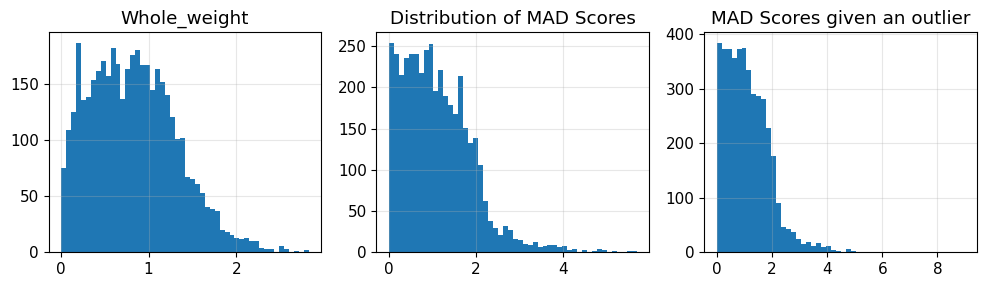

In [19]:
# Run on Google Colab -- requires internet access
# Listing 2.1: MAD on the abalone Whole_weight column
import pandas as pd
import numpy as np
import statistics
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    mad_scores = [abs(x - median) / median_deviation for x in data]
    return mad_scores

data = fetch_openml("abalone", version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
pd.Series(data['Whole_weight']).hist(bins=50, ax=ax[0])
ax[0].set_title("Whole_weight")

mad_scores = calc_MAD(data['Whole_weight'])
pd.Series(mad_scores).hist(bins=50, ax=ax[1])
ax[1].set_title("Distribution of MAD Scores")

mad_scores = calc_MAD(np.concatenate([data['Whole_weight'], [4.0]]))
pd.Series(mad_scores).hist(bins=50, ax=ax[2])
ax[2].set_title("MAD Scores given an outlier")
plt.tight_layout()
plt.show()

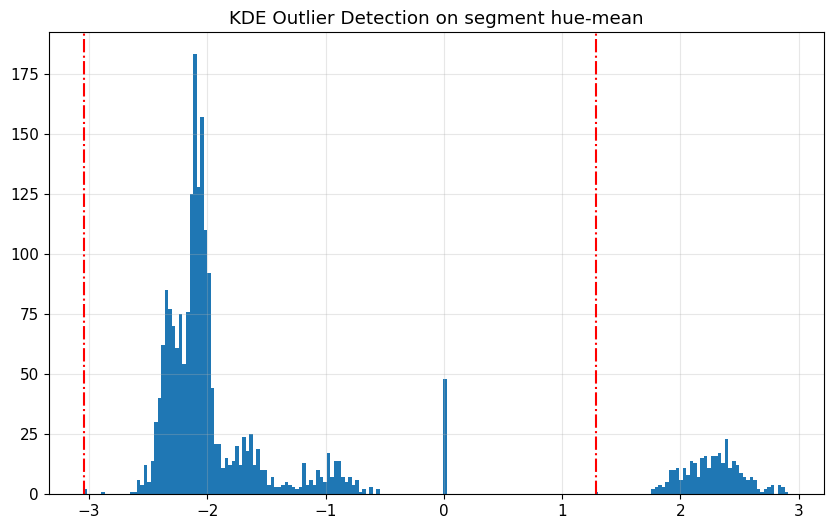

In [20]:
# Run on Google Colab -- requires internet access
# Listing 2.4: KDE on segment hue-mean
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

X = data['hue-mean'].values.reshape(-1, 1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X)
kde_scores = pd.Series(kde.score_samples(X))

q1 = kde_scores.quantile(0.25)
q3 = kde_scores.quantile(0.75)
iqr = q3 - q1
threshold = q1 - (2.2 * iqr)

rare_values = [data['hue-mean'][x] for x in range(len(data)) if kde_scores[x] < threshold]

fig, ax = plt.subplots()
plt.hist(data['hue-mean'], bins=200)
for rare_value in rare_values:
    ax.axvline(rare_value, color='red', linestyle='-.')
plt.title('KDE Outlier Detection on segment hue-mean')
plt.show()

In [21]:
# Run on Google Colab -- requires internet access
# Listing 2.5: kthNN on segment hue-mean
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import BallTree

data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

X = data['hue-mean'].values.reshape(-1, 1)
tree = BallTree(X, leaf_size=2)
dist, ind = tree.query(X, k=26)
max_dist_arr = pd.Series([max(x) for x in dist])

print(f"Score range: [{max_dist_arr.min():.4f}, {max_dist_arr.max():.4f}]")
print(f"Median score: {max_dist_arr.median():.4f}")

Score range: [0.0000, 0.6239]
Median score: 0.0054


In [22]:
# Run on Google Colab -- requires internet access
# Listing 2.8: Combining MAD scores across features (segment dataset)
import pandas as pd
import numpy as np
import statistics
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml

def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    if median_deviation == 0:
        mean_deviation = statistics.mean(deviations)
        return [abs(x - median) / mean_deviation for x in data]
    return [abs(x - median) / median_deviation for x in data]

data = fetch_openml('segment', version=1, parser='auto')
df = pd.DataFrame(data.data, columns=data.feature_names)

total_mad_scores = np.zeros(len(df))
for col_name in df.columns:
    if df[col_name].nunique() == 1:
        continue
    mad_scores = calc_MAD(df[col_name].tolist())
    mad_scores = np.array(mad_scores).reshape(-1, 1)
    transformer = MinMaxScaler().fit(mad_scores)
    col_mad_scores = transformer.transform(mad_scores).reshape(1, -1)[0]
    total_mad_scores += col_mad_scores

print("Top 10 rows by combined MAD score:")
top_idx = np.argsort(total_mad_scores)[-10:][::-1]
for idx in top_idx:
    print(f"  Row {idx}: total score = {total_mad_scores[idx]:.3f}")

Top 10 rows by combined MAD score:
  Row 1112: total score = 7.921
  Row 514: total score = 7.693
  Row 1748: total score = 7.642
  Row 1637: total score = 7.573
  Row 1930: total score = 7.525
  Row 594: total score = 7.458
  Row 1320: total score = 7.453
  Row 861: total score = 7.453
  Row 102: total score = 7.452
  Row 1508: total score = 7.443
